Data Loading

In [ ]:
# Loading

from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("postflop_500k_train_set_game_scenario_information.csv")

df.head()
df.info()

Saving postflop_500k_train_set_game_scenario_information.csv to postflop_500k_train_set_game_scenario_information.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Unnamed: 0          500000 non-null  int64 
 1   preflop_action      500000 non-null  object
 2   board_flop          500000 non-null  object
 3   board_turn          500000 non-null  object
 4   board_river         500000 non-null  object
 5   aggressor_position  500000 non-null  object
 6   postflop_action     500000 non-null  object
 7   evaluation_at       500000 non-null  object
 8   available_moves     500000 non-null  object
 9   pot_size            500000 non-null  int64 
 10  hero_position       500000 non-null  object
 11  holding             500000 non-null  object
 12  correct_decision    500000 non-null  object
dtypes: int64(2), object(11)
memory 

In [ ]:
# Basic Cleaning
df = df.rename(columns={"Unnamed: 0": "Index"})

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert pot size to numeric (just in case)
df["pot_size"] = pd.to_numeric(df["pot_size"], errors="coerce")

# Make sure categorical columns are strings
cat_cols = [
    "preflop_action", "board_flop", "board_turn", "board_river",
    "aggressor_position", "postflop_action", "evaluation_at",
    "hero_position", "holding", "correct_decision"
]

for col in cat_cols:
    df[col] = df[col].astype(str)

df.head()

,Index,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,available_moves,pot_size,hero_position,holding,correct_decision
0,0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,"['Check', 'Bet 17']",21,IP,AhKd,Check
1,1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,"['Fold', 'Call', 'Raise 41']",27,OOP,Tc9c,Call
2,2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,"['Fold', 'Call']",151,IP,QsQh,Call
3,3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,"['Check', 'Bet 13']",17,IP,JcTc,Check
4,4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,"['Check', 'Bet 29']",39,IP,Ac5c,Bet 29


In [ ]:
def simplify_action(action):
    action = action.lower()

    if "bet" in action or "raise" in action:
        return "Bet/Raise"
    elif "check" in action:
        return "Check"
    elif "call" in action:
        return "Call"
    elif "fold" in action:
        return "Fold"
    else:
        return "Other"

df["decision_category"] = df["correct_decision"].apply(simplify_action)

df.head()


,Index,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,available_moves,pot_size,hero_position,holding,correct_decision,decision_category
0,0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,"['Check', 'Bet 17']",21,IP,AhKd,Check,Check
1,1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,"['Fold', 'Call', 'Raise 41']",27,OOP,Tc9c,Call,Call
2,2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,"['Fold', 'Call']",151,IP,QsQh,Call,Call
3,3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,"['Check', 'Bet 13']",17,IP,JcTc,Check,Check
4,4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,"['Check', 'Bet 29']",39,IP,Ac5c,Bet 29,Bet/Raise


Basic Decision Tree

In [ ]:
# Install any missing packages
!pip install pandas scikit-learn matplotlib seaborn graphviz xgboost optuna shap mlxtend

import pandas as pd
import numpy as np

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import optuna
import shap

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import ast
import re
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All dependencies loaded successfully.")

All dependencies loaded successfully.


In [ ]:
# Drop columns that are too complex / unstructured for baseline
drop_cols = [
    'preflop_action',   # sequence text (can engineer later)
    'postflop_action',   # sequence text (can engineer later)
    'correct_decision'   # duplicate of target
]

df_basic = df.drop(columns=drop_cols)

# Target variable
y = df_basic['decision_category']

# Basic feature engineering

# Encode available_moves (count + flags)
df_basic['num_moves'] = df_basic['available_moves'].apply(lambda x: len(eval(x)))

df_basic['can_raise'] = df_basic['available_moves'].apply(lambda x: 'Raise' in x)
df_basic['can_bet'] = df_basic['available_moves'].apply(lambda x: 'Bet' in x)

# Simplify holding (just rank strength proxy: pair vs not)
def is_pair(hand):
    return hand[0] == hand[2]

df_basic['is_pair'] = df_basic['holding'].apply(is_pair)

# Drop raw text columns after extracting signal
X = df_basic.drop(columns=['decision_category', 'available_moves', 'holding'])

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

Go with the simple target for now, stretch goal to explore others

Will explore more complex numerical embeddings rather than converting available moves, holding, possibly preflop / postflop action in advanced models. Also board_flop

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(
    max_depth=5,        # prevent overfitting
    min_samples_leaf=10,
    random_state=42
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.59874
F1 (weighted): 0.5606216864998234

Classification Report:
              precision    recall  f1-score   support

   Bet/Raise       0.61      0.18      0.28     25000
        Call       0.52      0.66      0.58     25000
       Check       0.71      0.98      0.82     25000
        Fold       0.54      0.57      0.56     25000

    accuracy                           0.60    100000
   macro avg       0.60      0.60      0.56    100000
weighted avg       0.60      0.60      0.56    100000



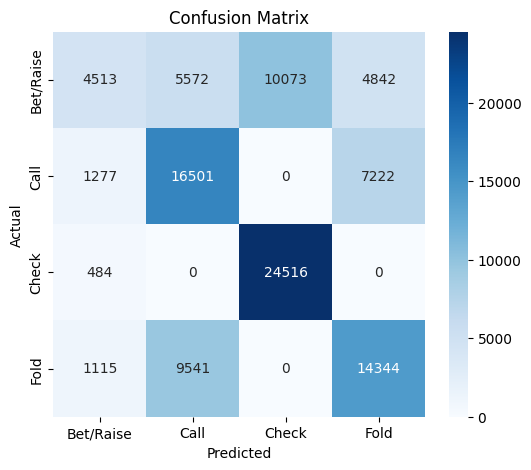

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

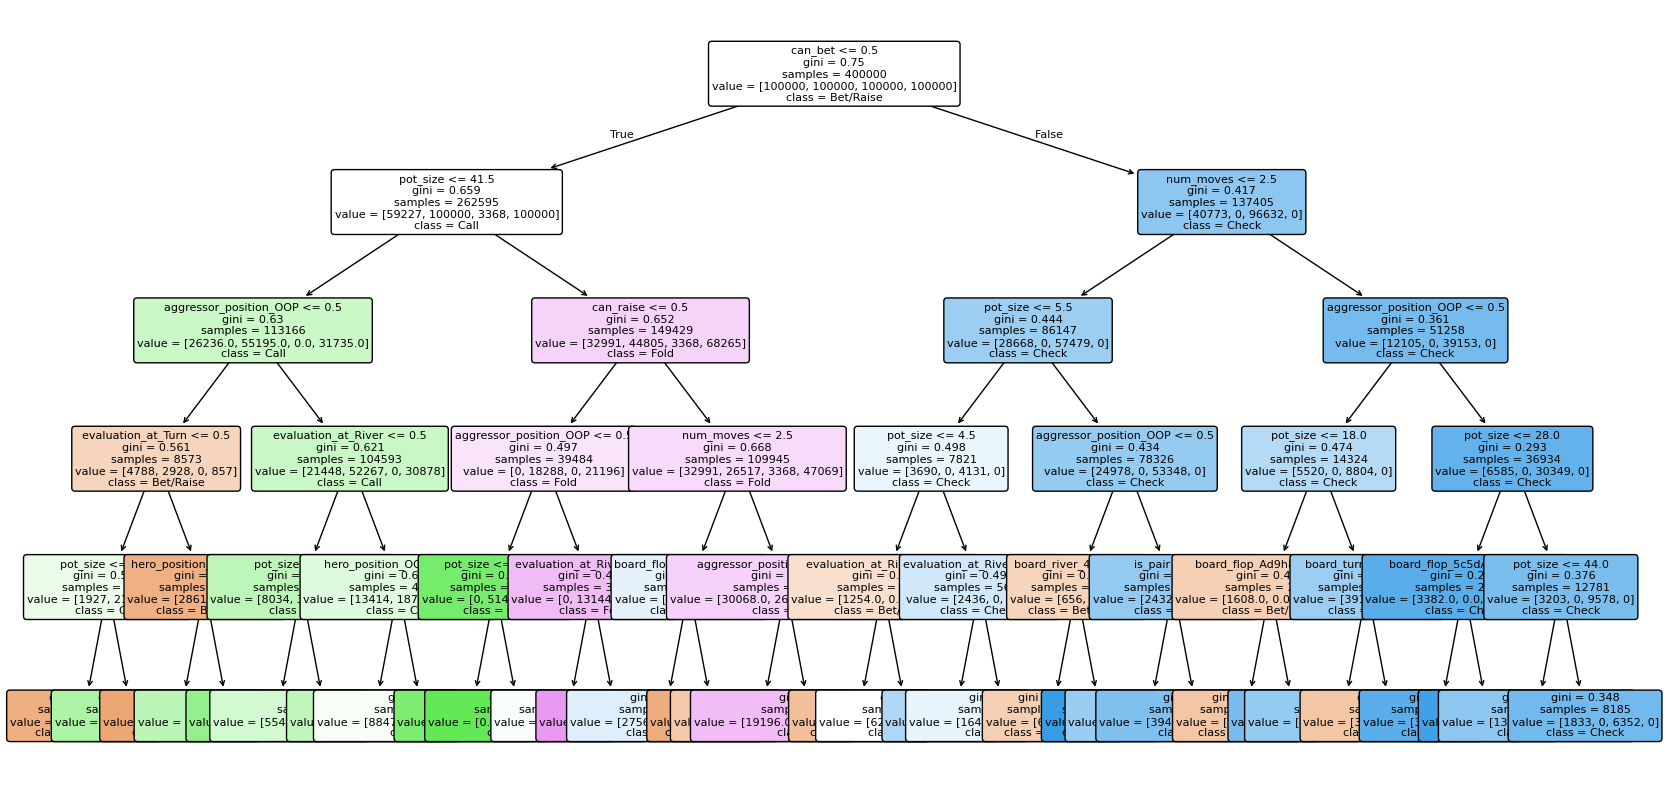

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [ ]:
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

|--- can_bet <= 0.50
|   |--- pot_size <= 41.50
|   |   |--- aggressor_position_OOP <= 0.50
|   |   |   |--- evaluation_at_Turn <= 0.50
|   |   |   |   |--- pot_size <= 22.50
|   |   |   |   |   |--- class: Bet/Raise
|   |   |   |   |--- pot_size >  22.50
|   |   |   |   |   |--- class: Call
|   |   |   |--- evaluation_at_Turn >  0.50
|   |   |   |   |--- hero_position_OOP <= 0.50
|   |   |   |   |   |--- class: Bet/Raise
|   |   |   |   |--- hero_position_OOP >  0.50
|   |   |   |   |   |--- class: Call
|   |   |--- aggressor_position_OOP >  0.50
|   |   |   |--- evaluation_at_River <= 0.50
|   |   |   |   |--- pot_size <= 12.50
|   |   |   |   |   |--- class: Call
|   |   |   |   |--- pot_size >  12.50
|   |   |   |   |   |--- class: Call
|   |   |   |--- evaluation_at_River >  0.50
|   |   |   |   |--- hero_position_OOP <= 0.50
|   |   |   |   |   |--- class: Call
|   |   |   |   |--- hero_position_OOP >  0.50
|   |   |   |   |   |--- class: Call
|   |--- pot_size >  41.50
|   |   |

can_bet                   0.734182
aggressor_position_OOP    0.078434
pot_size                  0.065723
can_raise                 0.046590
num_moves                 0.043150
evaluation_at_River       0.018741
hero_position_OOP         0.005403
evaluation_at_Turn        0.003841
board_turn_Kd             0.001283
is_pair                   0.001107
board_flop_Ad9h8h         0.000593
board_flop_Qc8cAc         0.000379
board_flop_5c5dAh         0.000331
board_river_4c            0.000243
board_flop_7d6c4h         0.000000
dtype: float64


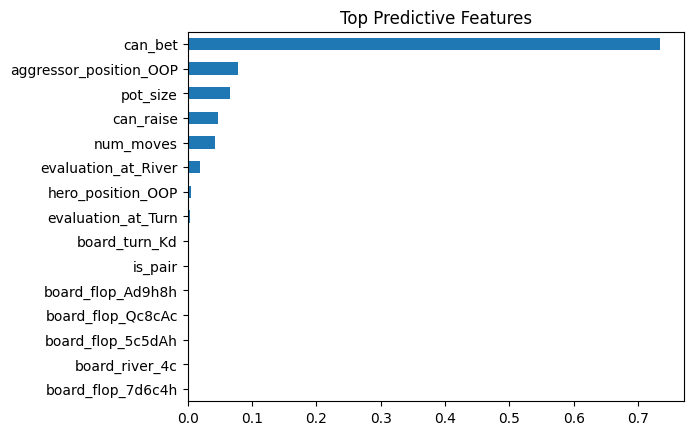

In [ ]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

importances.head(15).plot(kind='barh')
plt.title("Top Predictive Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
sample = X_test.iloc[0:1]
prediction = clf.predict(sample)

node_indicator = clf.decision_path(sample)
leaf_id = clf.apply(sample)

feature = clf.tree_.feature
threshold = clf.tree_.threshold

print("Prediction:", prediction[0])
print("\nDecision path:\n")

for node_id in node_indicator.indices:
    if leaf_id[0] == node_id:
        print(f"--> Reached leaf node {node_id}")
        continue

    if sample.iloc[0, feature[node_id]] <= threshold[node_id]:
        decision = "<="
    else:
        decision = ">"

    print(f"{X.columns[feature[node_id]]} {decision} {threshold[node_id]:.2f}")

Prediction: Call

Decision path:

can_bet <= 0.50
pot_size <= 41.50
aggressor_position_OOP > 0.50
evaluation_at_River > 0.50
hero_position_OOP <= 0.50
--> Reached leaf node 15


Optimizations (Engineered Complex Features)

In [ ]:
# ============================================================
# BLOCK 1: Card & Hand Strength Feature Engineering
# ============================================================
from itertools import combinations
import re

RANKS = {'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9,
         'T':10,'J':11,'Q':12,'K':13,'A':14}
RANK_CHARS = list(RANKS.keys())

def parse_card(card_str):
    """Returns (rank_int, suit_char) from e.g. 'Ah', 'Tc'"""
    return RANKS[card_str[0]], card_str[1]

def parse_hand(holding):
    """Parse 2-card holding string like 'AhKd' -> list of (rank, suit)"""
    return [parse_card(holding[i:i+2]) for i in range(0, len(holding), 2)]

def hand_features(holding):
    cards = parse_hand(holding)
    r1, s1 = cards[0]
    r2, s2 = cards[1]
    high = max(r1, r2)
    low  = min(r1, r2)
    return {
        'hand_high_rank':   high,
        'hand_low_rank':    low,
        'hand_is_pair':     int(r1 == r2),
        'hand_is_suited':   int(s1 == s2),
        'hand_is_connected': int(abs(r1 - r2) == 1),
        'hand_gap':         abs(r1 - r2),          # 0=pair,1=connected,...
        'hand_has_ace':     int(14 in (r1, r2)),
        'hand_has_broadway': int(high >= 10),        # T,J,Q,K,A
        'hand_rank_sum':    r1 + r2,
    }

# --- Board parsing ---
def parse_board(flop, turn, river):
    """Return list of (rank,suit) for all community cards dealt so far."""
    raw = ' '.join(filter(lambda x: isinstance(x, str) and x not in ['nan','None',''],
                          [flop, turn, river]))
    tokens = re.findall(r'[2-9TJQKA][cdhs]', raw)
    return [parse_card(t) for t in tokens]

def board_features(flop, turn, river):
    cards = parse_board(flop, turn, river)
    n = len(cards)
    if n == 0:
        return {k: 0 for k in ['board_n_cards','board_is_monotone','board_n_suits',
                                'board_paired','board_has_ace','board_has_broadway',
                                'board_high_rank','board_low_rank','board_connectedness',
                                'board_rank_spread']}
    ranks = sorted([c[0] for c in cards], reverse=True)
    suits = [c[1] for c in cards]
    n_suits = len(set(suits))
    paired = int(len(ranks) != len(set(ranks)))
    spread = ranks[0] - ranks[-1] if n > 1 else 0
    # Connectedness: avg gap between consecutive sorted ranks
    gaps = [ranks[i]-ranks[i+1] for i in range(len(ranks)-1)]
    connectedness = round(sum(gaps)/len(gaps), 2) if gaps else 0

    return {
        'board_n_cards':       n,
        'board_is_monotone':   int(n_suits == 1),
        'board_n_suits':       n_suits,
        'board_paired':        paired,
        'board_has_ace':       int(14 in ranks),
        'board_has_broadway':  int(any(r >= 10 for r in ranks)),
        'board_high_rank':     ranks[0],
        'board_low_rank':      ranks[-1],
        'board_connectedness': connectedness,
        'board_rank_spread':   spread,
    }

# Equity proxy: how well does hero's hand interact with the board?
def hand_board_interaction(holding, flop, turn, river):
    h_cards = parse_hand(holding)
    b_cards = parse_board(flop, turn, river)
    all_cards = h_cards + b_cards
    h_ranks = [c[0] for c in h_cards]
    h_suits = [c[1] for c in h_cards]
    b_ranks = [c[0] for c in b_cards]
    b_suits = [c[1] for c in b_cards]

    # Pair on board matches hero card
    hero_pairs_board = int(any(r in b_ranks for r in h_ranks))
    # Flush draw: hero suited + 2+ board cards same suit
    flush_draw = 0
    for s in set(h_suits):
        if h_suits.count(s) == 2 or b_suits.count(s) >= 2:
            if (h_suits + b_suits).count(s) >= 4:
                flush_draw = 1
    # Straight draw proxy: hero ranks close to board ranks
    all_ranks = sorted(set(h_ranks + b_ranks))
    max_consec = 1; cur = 1
    for i in range(1, len(all_ranks)):
        if all_ranks[i] - all_ranks[i-1] == 1:
            cur += 1; max_consec = max(max_consec, cur)
        else:
            cur = 1
    straight_draw = int(max_consec >= 4)
    # Overpair: both hero cards beat all board cards
    overpair = int(len(b_ranks) > 0 and min(h_ranks) > max(b_ranks)) if b_ranks else 0

    return {
        'hb_hero_pairs_board':  hero_pairs_board,
        'hb_flush_draw':        flush_draw,
        'hb_straight_draw':     straight_draw,
        'hb_overpair':          overpair,
        'hb_hero_high_on_board': int(len(b_ranks) > 0 and max(h_ranks) >= max(b_ranks)) if b_ranks else 0,
    }

# Apply all card features
card_feats = df.apply(lambda row: {
    **hand_features(row['holding']),
    **board_features(row['board_flop'], row['board_turn'], row['board_river']),
    **hand_board_interaction(row['holding'], row['board_flop'], row['board_turn'], row['board_river'])
}, axis=1)

df_cards = pd.DataFrame(list(card_feats))
print(df_cards.head())
print(df_cards.shape)

   hand_high_rank  hand_low_rank  hand_is_pair  hand_is_suited  \
0              14             13             0               0   
1              10              9             0               1   
2              12             12             1               0   
3              11             10             0               1   
4              14              5             0               1   

   hand_is_connected  hand_gap  hand_has_ace  hand_has_broadway  \
0                  1         1             1                  1   
1                  1         1             0                  1   
2                  0         0             0                  1   
3                  1         1             0                  1   
4                  0         9             1                  1   

   hand_rank_sum  board_n_cards  ...  board_has_broadway  board_high_rank  \
0             27              5  ...                   1               14   
1             19              5  ...          

In [ ]:
# ============================================================
# BLOCK 2: Postflop & Preflop Action Sequence Features
# ============================================================

def postflop_action_features(action_seq):
    """
    Parse postflop action strings like:
    'OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealcards/...'
    """
    if not isinstance(action_seq, str):
        return {}

    actions = action_seq.split('/')
    n_actions      = len(actions)
    n_bets         = sum(1 for a in actions if 'BET'   in a)
    n_raises       = sum(1 for a in actions if 'RAISE' in a)
    n_checks       = sum(1 for a in actions if 'CHECK' in a)
    n_calls        = sum(1 for a in actions if 'CALL'  in a)
    n_folds        = sum(1 for a in actions if 'FOLD'  in a)
    n_streets      = sum(1 for a in actions if 'dealcards' in a)
    aggression_idx = (n_bets + n_raises) / max(n_actions, 1)

    # Was hero (OOP or IP) the last aggressor?
    bet_raise_actions = [a for a in actions if 'BET' in a or 'RAISE' in a]
    last_aggressor = bet_raise_actions[-1][:3] if bet_raise_actions else 'NON'

    # Extract largest bet size seen
    sizes = re.findall(r'(?:BET|RAISE)_(\d+)', action_seq)
    max_bet_seen   = max([int(s) for s in sizes], default=0)
    total_bet_seen = sum([int(s) for s in sizes])

    return {
        'pf_n_actions':       n_actions,
        'pf_n_bets':          n_bets,
        'pf_n_raises':        n_raises,
        'pf_n_checks':        n_checks,
        'pf_n_calls':         n_calls,
        'pf_n_folds':         n_folds,
        'pf_n_streets':       n_streets,
        'pf_aggression_idx':  round(aggression_idx, 3),
        'pf_last_aggressor':  last_aggressor,   # will one-hot later
        'pf_max_bet_seen':    max_bet_seen,
        'pf_total_bet_seen':  total_bet_seen,
    }

def preflop_action_features(preflop_seq):
    """
    Parse preflop strings like 'UTG/2.0bb/CO/6.5bb/UTG/call'
    """
    if not isinstance(preflop_seq, str):
        return {}

    tokens   = preflop_seq.split('/')
    n_raises = sum(1 for t in tokens if re.match(r'\d+\.?\d*bb', t))
    n_callers = sum(1 for t in tokens if t == 'call')
    # Largest preflop raise size
    sizes    = [float(t.replace('bb','')) for t in tokens if re.match(r'\d+\.?\d*bb', t)]
    max_pf_raise = max(sizes, default=2.0)
    n_players_pf = len(set(t for t in tokens if t in
                            ['UTG','UTG1','MP','CO','BTN','SB','BB']))

    return {
        'preflop_n_raises':   n_raises,
        'preflop_n_callers':  n_callers,
        'preflop_max_raise':  max_pf_raise,
        'preflop_n_players':  n_players_pf,
        'preflop_3bet_plus':  int(n_raises >= 2),
    }

pf_feats  = df['postflop_action'].apply(postflop_action_features)
pre_feats = df['preflop_action'].apply(preflop_action_features)

df_postflop = pd.DataFrame(list(pf_feats))
df_preflop  = pd.DataFrame(list(pre_feats))

print("Postflop action features:", df_postflop.shape)
print("Preflop action features: ", df_preflop.shape)

Postflop action features: (500000, 11)
Preflop action features:  (500000, 5)


In [ ]:
# ============================================================
# BLOCK 3: Spot, Position & Available Moves Features
# ============================================================
import ast

POSITION_ORDER = {'BB':0,'SB':1,'UTG':2,'UTG1':3,'MP':4,'CO':5,'BTN':6,'IP':7,'OOP':0}

def position_features(hero_pos, aggressor_pos):
    hero_val = POSITION_ORDER.get(str(hero_pos).strip(), -1)
    agg_val  = POSITION_ORDER.get(str(aggressor_pos).strip(), -1)
    in_position = int(hero_pos == 'IP' or hero_val > agg_val)
    return {
        'pos_hero_numeric':  hero_val,
        'pos_agg_numeric':   agg_val,
        'pos_in_position':   in_position,
        'pos_is_blind':      int(hero_pos in ('BB','SB')),
    }

def street_features(evaluation_at):
    street_map = {'Flop':0, 'Turn':1, 'River':2}
    return {
        'street_numeric': street_map.get(str(evaluation_at).strip(), -1),
        'street_is_river': int(str(evaluation_at).strip() == 'River'),
        'street_is_flop':  int(str(evaluation_at).strip() == 'Flop'),
    }

def moves_features(available_moves, spot_size):
    try:
        moves = ast.literal_eval(available_moves) if isinstance(available_moves, str) else []
    except:
        moves = []

    n_moves    = len(moves)
    can_raise  = int(any('Raise' in m for m in moves))
    can_bet    = int(any('Bet'   in m for m in moves))
    can_check  = int(any('Check' in m for m in moves))
    can_fold   = int(any('Fold'  in m for m in moves))

    # Extract raise/bet sizes from move labels e.g. "Raise 41", "Bet 17"
    sizes = []
    for m in moves:
        nums = re.findall(r'\d+', m)
        sizes.extend([int(n) for n in nums])
    max_move_size = max(sizes, default=0)
    min_move_size = min(sizes, default=0)

    # Pot-relative sizing
    try:
        spot = float(spot_size)
    except:
        spot = 0.0
    pot_relative_max = round(max_move_size / spot, 3) if spot > 0 else 0.0

    return {
        'move_n_options':      n_moves,
        'move_can_raise':      can_raise,
        'move_can_bet':        can_bet,
        'move_can_check':      can_check,
        'move_can_fold':       can_fold,
        'move_max_size':       max_move_size,
        'move_min_size':       min_move_size,
        'move_pot_relative':   pot_relative_max,
        'spot_size_numeric':   spot,
    }

pos_feats   = df.apply(lambda r: position_features(r['hero_position'], r['aggressor_position']), axis=1)
street_feats= df['evaluation_at'].apply(street_features)
move_feats  = df.apply(lambda r: moves_features(r['available_moves'], r['pot_size']), axis=1)

df_pos    = pd.DataFrame(list(pos_feats))
df_street = pd.DataFrame(list(street_feats))
df_moves  = pd.DataFrame(list(move_feats))

print("Position features:", df_pos.shape)
print("Street features:  ", df_street.shape)
print("Move features:    ", df_moves.shape)

Position features: (500000, 4)
Street features:   (500000, 3)
Move features:     (500000, 9)


In [ ]:
# ============================================================
# BLOCK 4: Assemble Full Feature Matrix & Train Advanced Tree
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# --- Concatenate all engineered feature blocks ---
df_advanced = pd.concat([
    df_cards,
    df_postflop,
    df_preflop,
    df_pos,
    df_street,
    df_moves,
], axis=1)

# --- One-hot encode any remaining categoricals ---
cat_cols = df_advanced.select_dtypes(include='object').columns.tolist()
print("Categorical cols to encode:", cat_cols)
df_advanced = pd.get_dummies(df_advanced, columns=cat_cols, drop_first=True)

# --- Target ---
y = df['decision_category']

# --- Drop any NaN columns / rows ---
df_advanced = df_advanced.fillna(0)

X = df_advanced
print(f"\nFinal feature matrix: {X.shape[0]} rows × {X.shape[1]} features")

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Advanced Decision Tree (tuned) ---
clf_adv = DecisionTreeClassifier(
    max_depth=8,              # deeper tree = richer poker logic
    min_samples_leaf=5,       # tighter leaves OK with richer features
    min_samples_split=10,
    class_weight='balanced',  # handles class imbalance
    criterion='gini',
    random_state=42
)
clf_adv.fit(X_train, y_train)

# --- Evaluation ---
y_pred_adv = clf_adv.predict(X_test)

print("=" * 50)
print("ADVANCED DECISION TREE RESULTS")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred_adv):.4f}")
print(f"F1 (wtd) : {f1_score(y_test, y_pred_adv, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adv))

# --- Cross-validation for robustness check ---
cv_scores = cross_val_score(clf_adv, X, y, cv=5, scoring='f1_weighted')
print(f"\n5-Fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Categorical cols to encode: ['pf_last_aggressor']

Final feature matrix: 500000 rows × 57 features
ADVANCED DECISION TREE RESULTS
Accuracy : 0.6859
F1 (wtd) : 0.6778

Classification Report:
              precision    recall  f1-score   support

   Bet/Raise       0.60      0.45      0.52     25000
        Call       0.63      0.70      0.66     25000
       Check       0.77      0.91      0.83     25000
        Fold       0.71      0.68      0.70     25000

    accuracy                           0.69    100000
   macro avg       0.68      0.69      0.68    100000
weighted avg       0.68      0.69      0.68    100000


5-Fold CV F1 (weighted): 0.6744 ± 0.0015


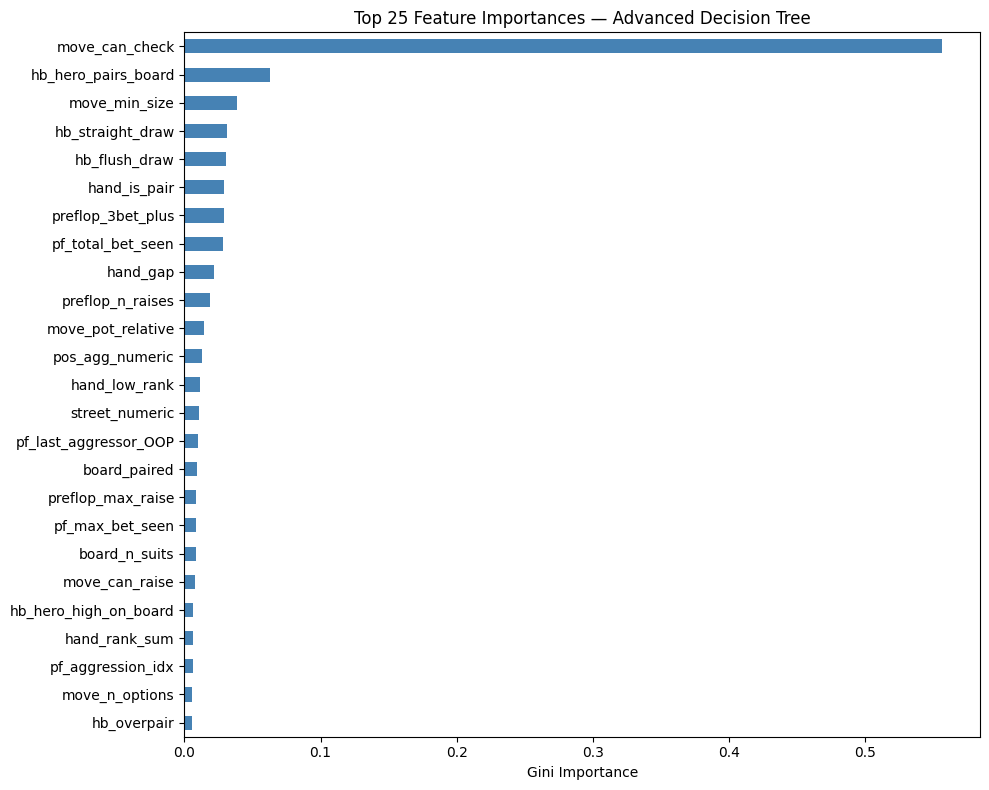


Top 25 Features:
move_can_check           0.556618
hb_hero_pairs_board      0.062630
move_min_size            0.038589
hb_straight_draw         0.031491
hb_flush_draw            0.030388
hand_is_pair             0.028812
preflop_3bet_plus        0.028740
pf_total_bet_seen        0.028384
hand_gap                 0.021657
preflop_n_raises         0.018475
move_pot_relative        0.014362
pos_agg_numeric          0.012758
hand_low_rank            0.011057
street_numeric           0.010551
pf_last_aggressor_OOP    0.009845
board_paired             0.009091
preflop_max_raise        0.008615
pf_max_bet_seen          0.008505
board_n_suits            0.008410
move_can_raise           0.007398
hb_hero_high_on_board    0.006307
hand_rank_sum            0.006222
pf_aggression_idx        0.006175
move_n_options           0.005823
hb_overpair              0.005475


In [ ]:
# ============================================================
# BLOCK 5: Feature Importance Analysis
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(clf_adv.feature_importances_, index=X.columns)
top_n = importances.nlargest(25).sort_values()

plt.figure(figsize=(10, 8))
top_n.plot(kind='barh', color='steelblue')
plt.title('Top 25 Feature Importances — Advanced Decision Tree')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

print("\nTop 25 Features:")
print(importances.nlargest(25).to_string())

- Can see more features with actual meaning
- Can see the hand relationship with the board (pairs, draws, etc.) pretty relevant
- Improved F1 / accuracy by about 7%, so solid optimization

Advanced Decision Tree

In [ ]:
# ============================================================
# BLOCK A: TF-IDF + SVD embeddings for sequence columns
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
import numpy as np

def make_sequence_embedder(n_components=20, max_features=300):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb',     # char n-grams capture poker token patterns
            ngram_range=(2, 5),     # e.g. "BET_", "_CALL", "RAISE"
            max_features=max_features,
            sublinear_tf=True,
        )),
        ('svd', TruncatedSVD(n_components=n_components, random_state=42)),
    ])

# Clean nulls
postflop_text = df['postflop_action'].fillna('').astype(str)
preflop_text  = df['preflop_action'].fillna('').astype(str)

# Fit embedders
postflop_embedder = make_sequence_embedder(n_components=25)
preflop_embedder  = make_sequence_embedder(n_components=15)

postflop_vecs = postflop_embedder.fit_transform(postflop_text)
preflop_vecs  = preflop_embedder.fit_transform(preflop_text)

# Name the columns
postflop_cols = [f'postflop_svd_{i}' for i in range(postflop_vecs.shape[1])]
preflop_cols  = [f'preflop_svd_{i}'  for i in range(preflop_vecs.shape[1])]

df_postflop_emb = pd.DataFrame(postflop_vecs, columns=postflop_cols)
df_preflop_emb  = pd.DataFrame(preflop_vecs,  columns=preflop_cols)

print(f"Postflop embedding: {df_postflop_emb.shape}")
print(f"Preflop embedding:  {df_preflop_emb.shape}")

Postflop embedding: (500000, 25)
Preflop embedding:  (500000, 15)


In [ ]:
# ============================================================
# BLOCK B: Target encoding for categoricals — no leakage
# ============================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

y_raw = df['decision_category']

le = LabelEncoder()
y_num = le.fit_transform(y_raw).astype(float)  # numpy array — that's fine
y_int = le.transform(y_raw)                     # for stratified splits

CAT_COLS = [
    'hero_position',
    'aggressor_position',
    'evaluation_at',
    'board_flop',
    'board_turn',
    'board_river',
]

def target_encode_cv(df_in, cat_cols, y_array, n_splits=5, smooth=10):
    """
    CV-safe target encoding with smoothing.
    y_array: numpy array (not a Series) — fixed to use positional indexing.
    """
    global_mean = y_array.mean()
    encoded = pd.DataFrame(index=df_in.index)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cat_cols:
        col_encoded = np.full(len(df_in), global_mean)  # default = global mean

        for train_idx, val_idx in skf.split(df_in, y_int):
            # Build a small df with the categorical col + target for this fold
            train_col   = df_in[col].iloc[train_idx].values
            train_y     = y_array[train_idx]              # numpy positional — no .iloc

            # Compute per-level stats on the train fold
            levels      = np.unique(train_col)
            level_stats = {}
            for lvl in levels:
                mask        = train_col == lvl
                count       = mask.sum()
                mean        = train_y[mask].mean()
                smoothed    = (count * mean + smooth * global_mean) / (count + smooth)
                level_stats[lvl] = smoothed

            # Apply to val fold
            val_col = df_in[col].iloc[val_idx].values
            for i, (pos, lvl) in enumerate(zip(val_idx, val_col)):
                col_encoded[pos] = level_stats.get(lvl, global_mean)

        encoded[f'te_{col}'] = col_encoded

    return encoded

df_target_enc = target_encode_cv(df, CAT_COLS, y_num)
print("Target-encoded features:", df_target_enc.shape)
print(df_target_enc.head())

Target-encoded features: (500000, 6)
   te_hero_position  te_aggressor_position  te_evaluation_at  te_board_flop  \
0          1.420797               1.571331          1.519410       1.539168   
1          1.638796               1.570880          1.533982       1.453544   
2          1.421516               0.997303          1.533698       1.539289   
3          1.420797               1.571331          1.519410       1.420389   
4          1.420797               1.571331          1.519410       1.432224   

   te_board_turn  te_board_river  
0       1.560555        1.473973  
1       1.432575        1.512804  
2       1.567092        1.476670  
3       1.352864        1.509454  
4       1.527720        1.409430  


In [ ]:
# ============================================================
# BLOCK C: Merge all tracks into one feature matrix
# ============================================================

# Your hand-crafted features from Blocks 1-3
# (df_cards, df_postflop, df_preflop, df_pos, df_street, df_moves)
df_handcrafted = pd.concat([
    df_cards,
    df_postflop,   # action-sequence hand-crafted stats
    df_preflop,
    df_pos,
    df_street,
    df_moves,
], axis=1)

# Drop any object cols that slipped through
df_handcrafted = df_handcrafted.select_dtypes(exclude='object')

# Merge all three tracks
df_full = pd.concat([
    df_handcrafted.reset_index(drop=True),
    df_postflop_emb.reset_index(drop=True),
    df_preflop_emb.reset_index(drop=True),
    df_target_enc.reset_index(drop=True),
], axis=1)

df_full = df_full.fillna(0)

print(f"Final matrix: {df_full.shape[0]} rows × {df_full.shape[1]} features")
print(f"  Hand-crafted:      {df_handcrafted.shape[1]}")
print(f"  Postflop SVD:      {df_postflop_emb.shape[1]}")
print(f"  Preflop SVD:       {df_preflop_emb.shape[1]}")
print(f"  Target-encoded:    {df_target_enc.shape[1]}")

X_full = df_full
y      = y_raw

Final matrix: 500000 rows × 101 features
  Hand-crafted:      55
  Postflop SVD:      25
  Preflop SVD:       15
  Target-encoded:    6


In [ ]:
# ============================================================
# FAST OPTUNA: subsample for tuning only
# ============================================================
from sklearn.model_selection import StratifiedShuffleSplit

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

X_arr = X_full.values.astype(np.float32)

# Use 50k rows for tuning — statistically representative, ~10x faster
sss = StratifiedShuffleSplit(n_splits=1, test_size=None, train_size=50_000, random_state=42)
tune_idx, _ = next(sss.split(X_arr, y_enc))

X_tune = X_arr[tune_idx]
y_tune = y_enc[tune_idx]

print(f"Tuning on {X_tune.shape[0]:,} rows  |  Full matrix: {X_arr.shape[0]:,} rows")

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'use_label_encoder': False,
        'eval_metric':       'mlogloss',
        'tree_method':       'hist',   # critical for large data — much faster
        'random_state':      42,
        'n_jobs':            -1,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_tune, y_tune, cv=cv,
                             scoring='f1_weighted', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest CV F1 (on tune subset): {study.best_value:.4f}")
print("Best params:", study.best_params)

Tuning on 50,000 rows  |  Full matrix: 500,000 rows


  0%|          | 0/40 [00:00<?, ?it/s]


Best CV F1 (on tune subset): 0.7676
Best params: {'n_estimators': 281, 'max_depth': 8, 'learning_rate': 0.1644490408133822, 'subsample': 0.961461594099727, 'colsample_bytree': 0.6212386459202095, 'min_child_weight': 8, 'reg_alpha': 0.00020674716485233845, 'reg_lambda': 0.010433543052831316}


- Lower end of number of estimators range, so we have enough data
- Can see that increasing depth helps
- Decently aggressive learning rate, clearer splits
- High subsample, rows aren't redundant (makes sense since it is a benchmark)
- Only 62% of features used, show redundant columns, helps generalization
- Minimal regularization, column dropping the preferred method of generalization

In [ ]:
# ============================================================
# BLOCK E: Final fit on FULL dataset with tuned params
# ============================================================
best_params = study.best_params
best_params.update({
    'use_label_encoder': False,
    'eval_metric':       'mlogloss',
    'tree_method':       'hist',     # keep this — speeds up full fit too
    'random_state':      42,
    'n_jobs':            -1,
})

X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

xgb_final = xgb.XGBClassifier(**best_params)
xgb_final.fit(X_train, y_train)

y_pred = xgb_final.predict(X_test)

print("=" * 55)
print("  EMBEDDING + XGBOOST RESULTS  (full 500k)")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 (wtd):  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

  EMBEDDING + XGBOOST RESULTS  (full 500k)
  Accuracy:  0.8536
  F1 (wtd):  0.8519

Classification Report:
              precision    recall  f1-score   support

   Bet/Raise       0.84      0.73      0.78     25000
        Call       0.82      0.86      0.84     25000
       Check       0.87      0.95      0.91     25000
        Fold       0.89      0.88      0.89     25000

    accuracy                           0.85    100000
   macro avg       0.85      0.85      0.85    100000
weighted avg       0.85      0.85      0.85    100000



- Can see vastly better results, up almost 20% in both categories
- Also took much longer to train however

In [ ]:
# ============================================================
# BLOCK G: Random Forest — large-data optimized
# ============================================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # was 500 — enough to compare fairly
    max_depth=20,            # was None (fully grown) — caps runaway trees
    min_samples_leaf=10,     # was 3 — larger leaves = faster on big data
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# Evaluate on the same tune subset to keep it fair and fast
rf.fit(X_tune, y_tune)
rf_pred = rf.predict(X_test)

print(f"Random Forest F1 (wtd): {f1_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"XGBoost F1 (wtd):       {f1_score(y_test, y_pred, average='weighted'):.4f}")

Random Forest F1 (wtd): 0.6982
XGBoost F1 (wtd):       0.8519


- Just using random forest doesn't improve results much
- XGBoost + extra training time the real improver

Optimizations (Minimize Tree Depth)

In [ ]:
# ============================================================
# BLOCK 1: Depth sweep — reusing X and y from Block 4
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# X and y are already defined from Block 4 — no changes needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

depths = list(range(1, 21))
results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=5,       # match Block 4 settings
        min_samples_split=10,
        class_weight='balanced',
        criterion='gini',
        random_state=42,
    )
    clf.fit(X_train, y_train)

    train_f1 = f1_score(y_train, clf.predict(X_train), average='weighted')
    test_f1  = f1_score(y_test,  clf.predict(X_test),  average='weighted')
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    cv_scores = cross_val_score(clf, X, y, cv=skf,
                                scoring='f1_weighted', n_jobs=-1)

    results.append({
        'depth':      depth,
        'train_f1':   round(train_f1, 4),
        'test_f1':    round(test_f1,  4),
        'cv_f1_mean': round(cv_scores.mean(), 4),
        'cv_f1_std':  round(cv_scores.std(),  4),
        'test_acc':   round(test_acc, 4),
        'n_leaves':   clf.get_n_leaves(),
        'n_nodes':    clf.tree_.node_count,
    })
    print(f"Depth {depth:2d} | Test F1: {test_f1:.4f} | "
          f"CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
          f"Leaves: {clf.get_n_leaves()}")

df_results = pd.DataFrame(results)
print("\n", df_results.to_string(index=False))

Depth  1 | Test F1: 0.3456 | CV F1: 0.3455 ± 0.0002 | Leaves: 2
Depth  2 | Test F1: 0.4930 | CV F1: 0.4919 ± 0.0007 | Leaves: 4
Depth  3 | Test F1: 0.5143 | CV F1: 0.5089 ± 0.0060 | Leaves: 8
Depth  4 | Test F1: 0.5618 | CV F1: 0.5584 ± 0.0028 | Leaves: 16
Depth  5 | Test F1: 0.5943 | CV F1: 0.5935 ± 0.0006 | Leaves: 32
Depth  6 | Test F1: 0.6332 | CV F1: 0.6318 ± 0.0027 | Leaves: 64
Depth  7 | Test F1: 0.6481 | CV F1: 0.6517 ± 0.0025 | Leaves: 128
Depth  8 | Test F1: 0.6778 | CV F1: 0.6735 ± 0.0014 | Leaves: 254
Depth  9 | Test F1: 0.6888 | CV F1: 0.6863 ± 0.0006 | Leaves: 496
Depth 10 | Test F1: 0.7001 | CV F1: 0.6990 ± 0.0005 | Leaves: 922
Depth 11 | Test F1: 0.7125 | CV F1: 0.7125 ± 0.0017 | Leaves: 1663
Depth 12 | Test F1: 0.7248 | CV F1: 0.7227 ± 0.0009 | Leaves: 2880
Depth 13 | Test F1: 0.7353 | CV F1: 0.7347 ± 0.0011 | Leaves: 4680
Depth 14 | Test F1: 0.7466 | CV F1: 0.7448 ± 0.0016 | Leaves: 7143
Depth 15 | Test F1: 0.7549 | CV F1: 0.7546 ± 0.0012 | Leaves: 10223
Depth 16 | Te

- Can see that increasing depth increases F1 pretty reliably
- Approaches the XGBoost level without needing all the optimizations
- Suggests that a player can utilize heuristics
- Slowly build up more skill as they take more factors into account

Frequent Itemsets

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Install & Imports
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from itertools import combinations

import warnings
warnings.filterwarnings("ignore", message="datetime.datetime.utcnow")

print("Imports loaded.")

Imports loaded.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Build Transaction DataFrame
# ═══════════════════════════════════════════════════════════════════════════════
#
# Strategy: mix raw categoricals (position, street) with engineered binary
# features from Blocks 1-3. Continuous features get binned.
# Output: a one-hot boolean DataFrame where each column is an "item".
# ═══════════════════════════════════════════════════════════════════════════════

txn_frames = []

# --- A. Position (from raw df — cleaner labels than numeric encoding) --------
if 'hero_position' in df.columns:
    txn_frames.append(pd.get_dummies(df['hero_position'], prefix='pos').astype(bool))

if 'aggressor_position' in df.columns:
    txn_frames.append(pd.get_dummies(df['aggressor_position'], prefix='agg').astype(bool))

# --- B. Street / evaluation point (from raw df) -----------------------------
if 'evaluation_at' in df.columns:
    txn_frames.append(pd.get_dummies(df['evaluation_at'], prefix='street').astype(bool))

# --- C. Binary card features (from df_cards, Block 1) -----------------------
# These are already 0/1 — just convert to bool.
card_binary_cols = [c for c in df_cards.columns if df_cards[c].dropna().isin([0, 1]).all()]
if card_binary_cols:
    card_bin = df_cards[card_binary_cols].fillna(0).astype(bool)
    # Prefix for clarity
    card_bin.columns = ['card_' + c if not c.startswith('card_') else c for c in card_bin.columns]
    txn_frames.append(card_bin)

# --- D. Binned card numerics (high_rank, low_rank, gap) ---------------------
# Map rank numbers to poker labels for readable itemset names
rank_labels = {14:'A', 13:'K', 12:'Q', 11:'J', 10:'T', 9:'9', 8:'8',
               7:'7', 6:'6', 5:'5', 4:'4', 3:'3', 2:'2'}

if 'high_rank' in df_cards.columns:
    hr = df_cards['high_rank'].map(rank_labels).fillna('?')
    txn_frames.append(pd.get_dummies(hr, prefix='hi').astype(bool))

if 'low_rank' in df_cards.columns:
    lr = df_cards['low_rank'].map(rank_labels).fillna('?')
    txn_frames.append(pd.get_dummies(lr, prefix='lo').astype(bool))

if 'gap' in df_cards.columns:
    gap_bins = pd.cut(df_cards['gap'], bins=[-1, 0, 1, 2, 4, 12],
                      labels=['pair', 'conn', 'gap1', 'gap2-4', 'gap5+'])
    txn_frames.append(pd.get_dummies(gap_bins, prefix='gap').astype(bool))

# --- E. Pot size bins (from raw df) -----------------------------------------
if 'pot_size' in df.columns:
    pot_q = pd.qcut(df['pot_size'], q=4, labels=['pot_Q1', 'pot_Q2', 'pot_Q3', 'pot_Q4'])
    txn_frames.append(pd.get_dummies(pot_q, prefix='').astype(bool))

# --- F. Action sequence features (from df_postflop / df_preflop) -------------
# Bin n_bets, n_raises, aggression_idx into interpretable categories
for feat_df, prefix in [(df_postflop, 'post'), (df_preflop, 'pre')]:
    if 'n_bets' in feat_df.columns:
        nb = pd.cut(feat_df['n_bets'], bins=[-1, 0, 1, 2, 20],
                     labels=[f'{prefix}_0bets', f'{prefix}_1bet', f'{prefix}_2bets', f'{prefix}_3+bets'])
        txn_frames.append(pd.get_dummies(nb).astype(bool))
    if 'n_raises' in feat_df.columns:
        nr = pd.cut(feat_df['n_raises'], bins=[-1, 0, 1, 2, 20],
                     labels=[f'{prefix}_0raises', f'{prefix}_1raise', f'{prefix}_2raises', f'{prefix}_3+raises'])
        txn_frames.append(pd.get_dummies(nr).astype(bool))

# --- G. Decision category (target) — include so we can mine rules like ------
#     {position=UTG, ace=True} -> Raise
txn_frames.append(pd.get_dummies(y, prefix='dec').astype(bool))

# --- Assemble ----------------------------------------------------------------
txn = pd.concat([f.reset_index(drop=True) for f in txn_frames], axis=1)
txn = txn.fillna(False)

# Drop columns with near-zero variance (< 0.5% support) — noise for FP-Growth
min_support_filter = 0.005
col_support = txn.mean()
low_support_cols = col_support[col_support < min_support_filter].index.tolist()
txn = txn.drop(columns=low_support_cols)

print(f"Transaction matrix: {txn.shape[0]:,} rows × {txn.shape[1]} items")
print(f"Dropped {len(low_support_cols)} items below {min_support_filter:.1%} support")
print(f"\nTop 20 items by support:")
print(col_support.drop(low_support_cols).sort_values(ascending=False).head(20).to_string())

Transaction matrix: 500,000 rows × 29 items
Dropped 0 items below 0.5% support

Top 20 items by support:
card_board_has_broadway       0.961482
agg_OOP                       0.875892
card_hand_has_broadway        0.833238
pos_IP                        0.640368
card_hb_hero_high_on_board    0.529628
card_hb_hero_pairs_board      0.529404
street_River                  0.520838
card_board_has_ace            0.447776
card_hand_is_suited           0.418766
street_Turn                   0.414306
card_board_paired             0.385732
pos_OOP                       0.359632
card_hand_has_ace             0.351848
_pot_Q1                       0.256522
_pot_Q2                       0.253080
dec_Check                     0.250000
dec_Call                      0.250000
dec_Bet/Raise                 0.250000
dec_Fold                      0.250000
_pot_Q4                       0.249060


Claude analysis:
- Decision categories are perfectly balanced at 25% each — that's a balanced dataset by design (or was resampled). That's great for the classifier but means the "bias" story is entirely in the input features, not the target distribution.
- 96% of boards have a broadway card — that's actually close to theoretical (with 5 board cards, the probability of at least one T+ is very high), so that one probably isn't bias so much as combinatorics.
- OOP aggressor at 87.5% and IP hero at 64% — this is a big one. Your dataset heavily skews toward spots where hero is in position facing an out-of-position aggressor. That's a real training bias the model is absorbing.
- Suited hands at 41.9% vs the theoretical 23.5% — nearly double. That's your preflop selection filter showing up clearly. Players fold offsuit junk, so suited hands are massively over-represented.
- Ace in hand at 35.2% vs theoretical ~15% — more than double. Same story: aces get played, rags get folded.
- River at 52%, Turn at 41% — interesting that river spots dominate. Flop spots seem underrepresented, which might mean the dataset captures later-street decisions more.

In [ ]:
###############################################################################
# CELL 3A — FP-Growth on Stratified Subsample (Fast Pass)
###############################################################################
#
# 500k rows with high-support items creates a combinatorial explosion.
# Solution: subsample 50k rows (same approach as your Optuna tuning),
# which preserves the distribution while running 10-50x faster.
###############################################################################

from sklearn.model_selection import StratifiedShuffleSplit

# --- Subsample 50k rows, stratified on decision ----------------------------
sss = StratifiedShuffleSplit(n_splits=1, train_size=50_000, random_state=42)
sample_idx, _ = next(sss.split(txn, y))
txn_sample = txn.iloc[sample_idx].reset_index(drop=True)

print(f"Sampled {len(txn_sample):,} rows for FP-Growth")
print(f"Item count: {txn_sample.shape[1]}")

# --- Also drop ultra-high-support items (>90%) from mining ----------------
# Items like card_board_has_broadway (96%) appear in nearly every itemset,
# drowning out the interesting patterns. We keep them in the data for
# reference but exclude from mining.
high_support = txn_sample.mean()
too_common = high_support[high_support > 0.90].index.tolist()
txn_mining = txn_sample.drop(columns=too_common)

print(f"Dropped {len(too_common)} near-universal items from mining: {too_common}")
print(f"Mining matrix: {txn_mining.shape[0]:,} × {txn_mining.shape[1]} items")

Sampled 50,000 rows for FP-Growth
Item count: 29
Dropped 1 near-universal items from mining: ['card_board_has_broadway']
Mining matrix: 50,000 × 28 items


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3B — Broad Patterns (20% support)
# ═══════════════════════════════════════════════════════════════════════════════
# Should run in under 30 seconds on 50k rows.

%%time

freq_broad = fpgrowth(txn_mining, min_support=0.20, use_colnames=True, max_len=4)
freq_broad['length'] = freq_broad['itemsets'].apply(len)
freq_broad = freq_broad.sort_values('support', ascending=False)

print(f"\nFrequent itemsets at 20% support: {len(freq_broad)}")
print(f"  Singletons : {(freq_broad['length']==1).sum()}")
print(f"  Pairs      : {(freq_broad['length']==2).sum()}")
print(f"  Triples    : {(freq_broad['length']==3).sum()}")
print(f"  Quads      : {(freq_broad['length']==4).sum()}")

print("\n--- Top 30 multi-item sets by support ---")
multi = freq_broad[freq_broad['length'] >= 2].head(30)
for _, row in multi.iterrows():
    items = ', '.join(sorted(row['itemsets']))
    print(f"  {row['support']:.3f}  ({row['support']*len(txn_mining):,.0f} rows)  {items}")


Frequent itemsets at 20% support: 139
  Singletons : 23
  Pairs      : 58
  Triples    : 47
  Quads      : 11

--- Top 30 multi-item sets by support ---
  0.712  (35,620 rows)  agg_OOP, card_hand_has_broadway
  0.542  (27,088 rows)  card_hand_has_broadway, pos_IP
  0.531  (26,568 rows)  agg_OOP, pos_IP
  0.525  (26,260 rows)  card_hand_has_broadway, card_hb_hero_high_on_board
  0.515  (25,730 rows)  agg_OOP, street_River
  0.468  (23,387 rows)  card_hand_has_broadway, card_hb_hero_pairs_board
  0.463  (23,154 rows)  agg_OOP, card_hb_hero_pairs_board
  0.437  (21,865 rows)  agg_OOP, card_hb_hero_high_on_board
  0.435  (21,748 rows)  agg_OOP, card_hand_has_broadway, card_hb_hero_high_on_board
  0.433  (21,646 rows)  agg_OOP, card_hand_has_broadway, pos_IP
  0.418  (20,922 rows)  card_hand_has_broadway, street_River
  0.416  (20,783 rows)  agg_OOP, card_hand_has_broadway, street_River
  0.403  (20,174 rows)  agg_OOP, card_hand_has_broadway, card_hb_hero_pairs_board
  0.396  (19,823 rows)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3C — Fine Patterns (10% support, max_len=3)
# ═══════════════════════════════════════════════════════════════════════════════
# Tighter max_len keeps the search space manageable.
# If this is still slow, bump to 4% or drop max_len to 2.

%%time

freq_fine = fpgrowth(txn_mining, min_support=0.10, use_colnames=True, max_len=3)
freq_fine['length'] = freq_fine['itemsets'].apply(len)
freq_fine = freq_fine.sort_values('support', ascending=False)

print(f"\nFrequent itemsets at 10% support: {len(freq_fine)}")
print(f"  Singletons : {(freq_fine['length']==1).sum()}")
print(f"  Pairs      : {(freq_fine['length']==2).sum()}")
print(f"  Triples    : {(freq_fine['length']==3).sum()}")


Frequent itemsets at 10% support: 435
  Singletons : 25
  Pairs      : 160
  Triples    : 250
CPU times: user 1min 12s, sys: 39 ms, total: 1min 12s
Wall time: 1min 14s


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Association Rules (Lift-Based Bias Detection)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Lift > 1 → items co-occur more than independence would predict → bias.
# We focus on rules with lift ≥ 1.5 (50% more frequent than expected).
# ═══════════════════════════════════════════════════════════════════════════════

rules = association_rules(freq_fine, metric='lift', min_threshold=1.5,
                          num_itemsets=len(freq_fine))
rules = rules.sort_values('lift', ascending=False)

print(f"Association rules (lift >= 1.5): {len(rules)}")

decision_cols = [c for c in txn_mining.columns if c.startswith('dec_')]

def has_decision(itemset):
    return any(item in decision_cols for item in itemset)

bias_rules = rules[~rules['consequents'].apply(has_decision) &
                    ~rules['antecedents'].apply(has_decision)].copy()
decision_rules = rules[rules['consequents'].apply(has_decision)].copy()

print(f"\n  Input-feature bias rules: {len(bias_rules)}")
print(f"  Decision-predicting rules: {len(decision_rules)}")

print("\n═══ TOP 25 BIAS RULES (input features only, by lift) ═══")
print(f"{'LHS':<45} {'→':>2} {'RHS':<30} {'Sup':>6} {'Conf':>6} {'Lift':>6}")
print("─" * 100)
for _, r in bias_rules.head(25).iterrows():
    lhs = ', '.join(sorted(r['antecedents']))
    rhs = ', '.join(sorted(r['consequents']))
    print(f"{lhs:<45} →  {rhs:<30} {r['support']:.3f} {r['confidence']:.3f} {r['lift']:.2f}")

print("\n═══ TOP 25 DECISION RULES (by lift) ═══")
print(f"{'LHS':<50} {'→':>2} {'Decision':<20} {'Sup':>6} {'Conf':>6} {'Lift':>6}")
print("─" * 100)
for _, r in decision_rules.head(25).iterrows():
    lhs = ', '.join(sorted(r['antecedents']))
    rhs = ', '.join(sorted(r['consequents']))
    print(f"{lhs:<50} →  {rhs:<20} {r['support']:.3f} {r['confidence']:.3f} {r['lift']:.2f}")


Association rules (lift >= 1.5): 118

  Input-feature bias rules: 60
  Decision-predicting rules: 29

═══ TOP 25 BIAS RULES (input features only, by lift) ═══
LHS                                            → RHS                               Sup   Conf   Lift
────────────────────────────────────────────────────────────────────────────────────────────────────
card_hand_has_ace                             →  card_board_has_ace, card_hb_hero_high_on_board 0.154 0.438 2.84
card_board_has_ace, card_hb_hero_high_on_board →  card_hand_has_ace              0.154 1.000 2.84
agg_IP                                        →  card_hand_has_broadway, street_Turn 0.101 0.825 2.30
card_hand_has_broadway, street_Turn           →  agg_IP                         0.101 0.283 2.30
agg_IP                                        →  street_Turn                    0.103 0.843 2.02
street_Turn                                   →  agg_IP                         0.103 0.248 2.02
street_Turn                        

In [ ]:
print(df_cards.columns.tolist())

['hand_high_rank', 'hand_low_rank', 'hand_is_pair', 'hand_is_suited', 'hand_is_connected', 'hand_gap', 'hand_has_ace', 'hand_has_broadway', 'hand_rank_sum', 'board_n_cards', 'board_is_monotone', 'board_n_suits', 'board_paired', 'board_has_ace', 'board_has_broadway', 'board_high_rank', 'board_low_rank', 'board_connectedness', 'board_rank_spread', 'hb_hero_pairs_board', 'hb_flush_draw', 'hb_straight_draw', 'hb_overpair', 'hb_hero_high_on_board']


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Theoretical vs Observed Baseline Comparison
# ═══════════════════════════════════════════════════════════════════════════════
#
# Compare observed frequencies against what a random deal would produce.
# Large deviations = preflop selection bias baked into the dataset.
# ═══════════════════════════════════════════════════════════════════════════════

# Theoretical probabilities for a random 2-card hand from a 52-card deck
# (These are well-known poker combinatorics)
theoretical = {
    'suited':       0.2353,   # 4 * C(13,2) / C(52,2) ... 312/1326
    'pair (gap=0)': 0.0588,   # 78/1326
    'connected':    0.1176,   # ~156/1326 (excluding wraps)
    'has_ace':      0.1493,   # 1 - C(48,2)/C(52,2)
    'broadway':     0.0905,   # both cards T+ ... rough
    'has_king':     0.1493,   # same math as ace
}

# Map to observed columns — adjust these names if your df_cards uses different ones
# The code tries several plausible column names for each concept
def find_col(df, candidates):
    """Return the first matching column name, or None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

observed = {}
col_map = {
    'suited':       ['hand_is_suited'],
    'pair (gap=0)': ['hand_is_pair'],
    'connected':    ['hand_is_connected'],
    'has_ace':      ['hand_has_ace'],
    'broadway':     ['hand_has_broadway'],
    'has_king':     [],
}

for concept, candidates in col_map.items():
    c = find_col(df_cards, candidates)
    if c is not None:
        observed[concept] = df_cards[c].mean()

# Compute has_ace / has_king from rank columns if not found directly
if 'has_ace' not in observed and 'high_rank' in df_cards.columns:
    observed['has_ace'] = (df_cards['high_rank'] == 14).mean()
if 'has_king' not in observed and 'high_rank' in df_cards.columns:
    observed['has_king'] = ((df_cards['high_rank'] == 13) |
                             (df_cards['low_rank'] == 13)).mean()
if 'pair (gap=0)' not in observed and 'gap' in df_cards.columns:
    observed['pair (gap=0)'] = (df_cards['gap'] == 0).mean()
if 'connected' not in observed and 'gap' in df_cards.columns:
    observed['connected'] = (df_cards['gap'] == 1).mean()

# Build comparison table
compare_rows = []
for concept, theo in theoretical.items():
    if concept in observed:
        obs = observed[concept]
        ratio = obs / theo if theo > 0 else np.nan
        compare_rows.append({
            'Feature': concept,
            'Theoretical': theo,
            'Observed': obs,
            'Ratio (Obs/Theo)': ratio,
            'Δ (pp)': (obs - theo) * 100,
        })

df_compare = pd.DataFrame(compare_rows)
print("═══ THEORETICAL vs OBSERVED HAND DISTRIBUTIONS ═══\n")
print(df_compare.to_string(index=False, float_format='{:.4f}'.format))
print()
for _, row in df_compare.iterrows():
    direction = "OVER" if row['Ratio (Obs/Theo)'] > 1 else "UNDER"
    print(f"  {row['Feature']:<15} → {direction}-represented by "
          f"{abs(row['Ratio (Obs/Theo)']-1)*100:.1f}% "
          f"({row['Δ (pp)']:+.1f} percentage points)")

# --- Position distribution ---------------------------------------------------
if 'hero_position' in df.columns:
    pos_dist = df['hero_position'].value_counts(normalize=True).sort_index()
    n_positions = len(pos_dist)
    uniform = 1.0 / n_positions

    print(f"\n═══ POSITION DISTRIBUTION (uniform would be {uniform:.3f} each) ═══\n")
    for pos, freq in pos_dist.items():
        bar = "█" * int(freq * 200)
        deviation = (freq - uniform) / uniform * 100
        print(f"  {pos:<6} {freq:.4f}  ({deviation:+.1f}% vs uniform)  {bar}")

═══ THEORETICAL vs OBSERVED HAND DISTRIBUTIONS ═══

     Feature  Theoretical  Observed  Ratio (Obs/Theo)  Δ (pp)
      suited       0.2353    0.4188            1.7797 18.3466
pair (gap=0)       0.0588    0.1978            3.3634 13.8970
   connected       0.1176    0.2038            1.7332  8.6230
     has_ace       0.1493    0.3518            2.3567 20.2548
    broadway       0.0905    0.8332            9.2070 74.2738

  suited          → OVER-represented by 78.0% (+18.3 percentage points)
  pair (gap=0)    → OVER-represented by 236.3% (+13.9 percentage points)
  connected       → OVER-represented by 73.3% (+8.6 percentage points)
  has_ace         → OVER-represented by 135.7% (+20.3 percentage points)
  broadway        → OVER-represented by 820.7% (+74.3 percentage points)

═══ POSITION DISTRIBUTION (uniform would be 0.500 each) ═══

  IP     0.6404  (+28.1% vs uniform)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████

- Supports previous analysis
- Since this is a benchmark, aligns with a good pre-flop understanding

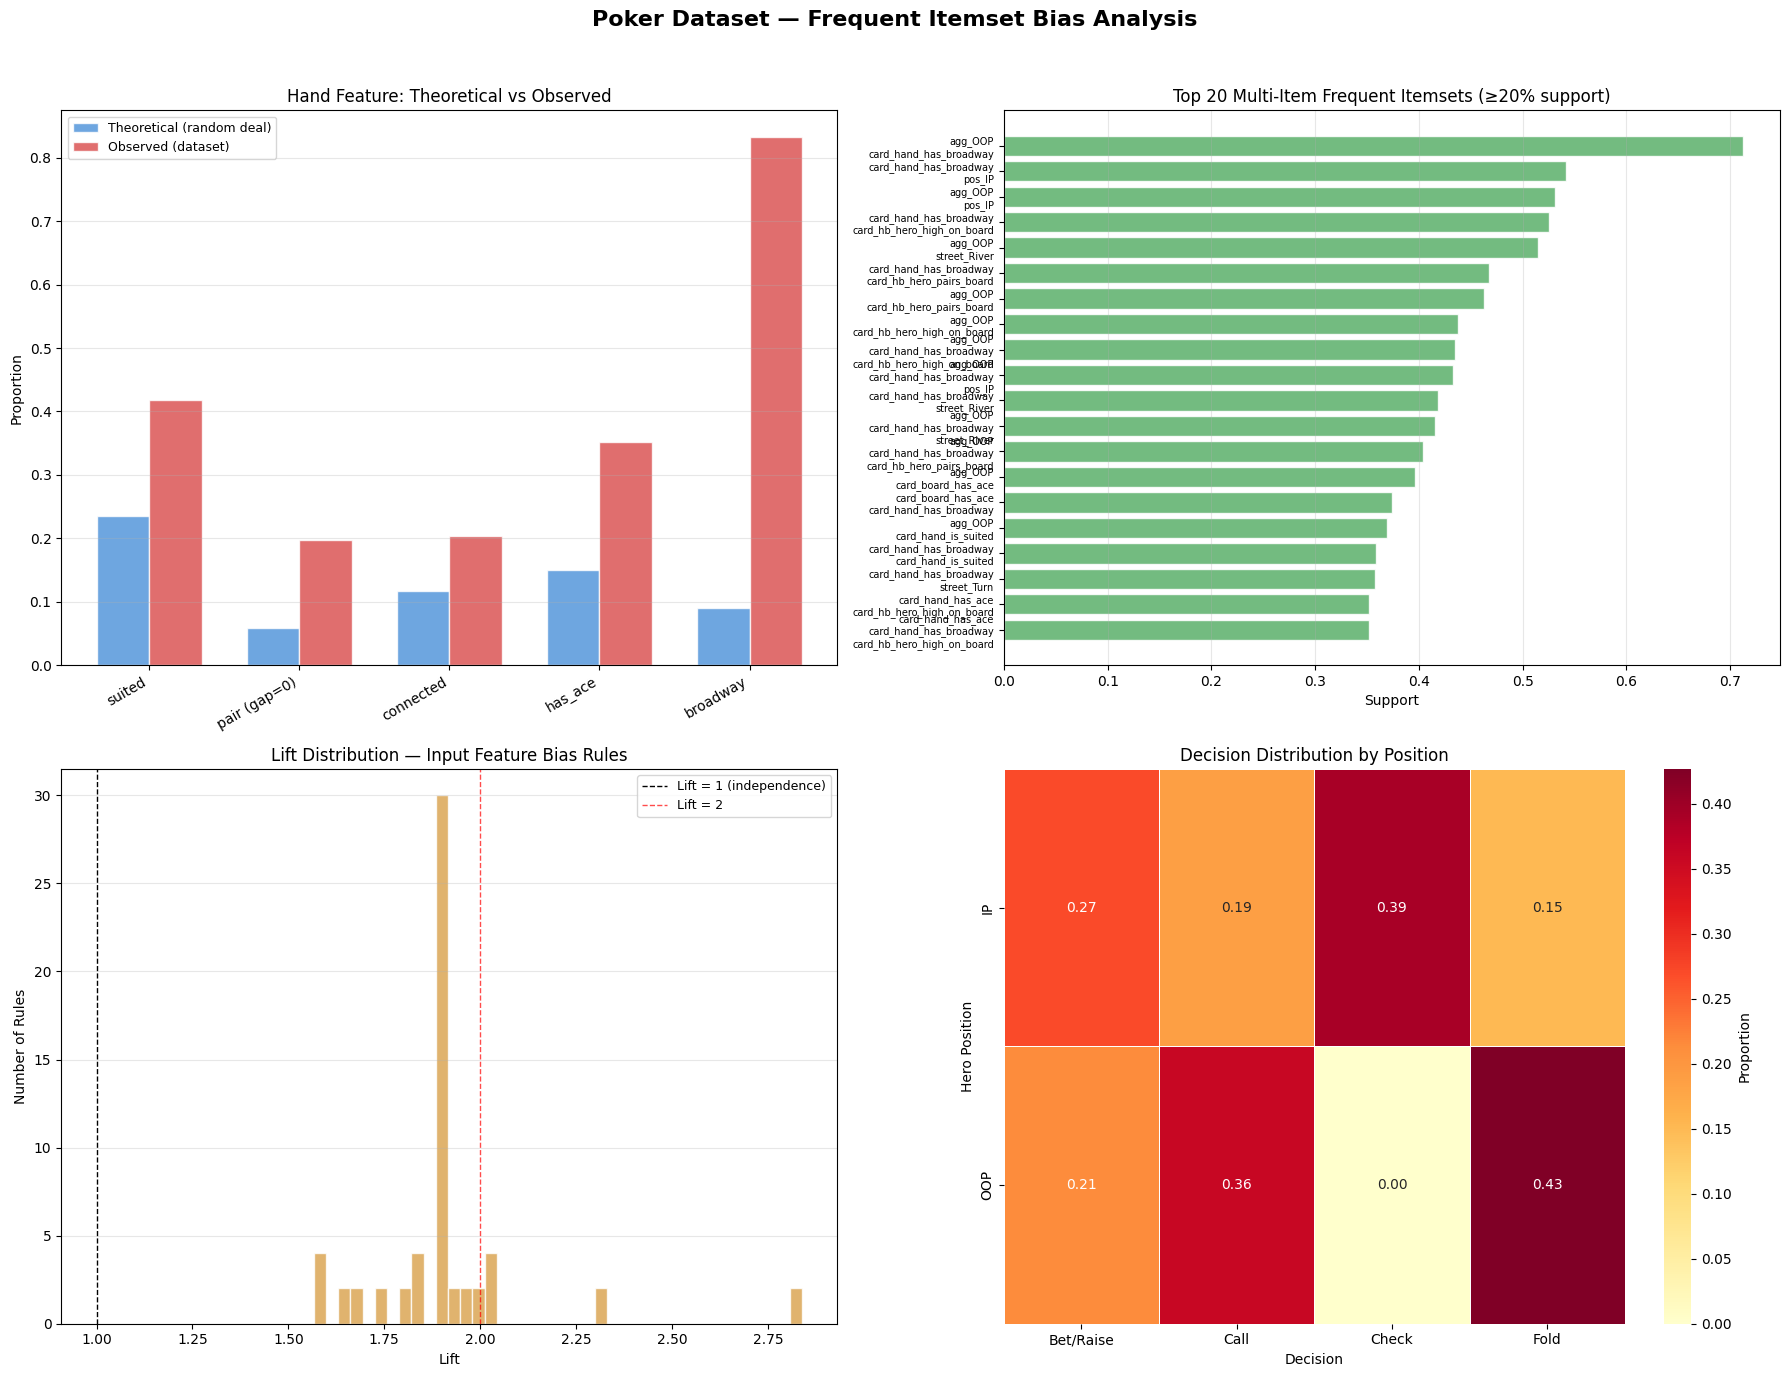

Saved: itemset_bias_analysis.png


/tmp/ipykernel_2703/852518595.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_decs))


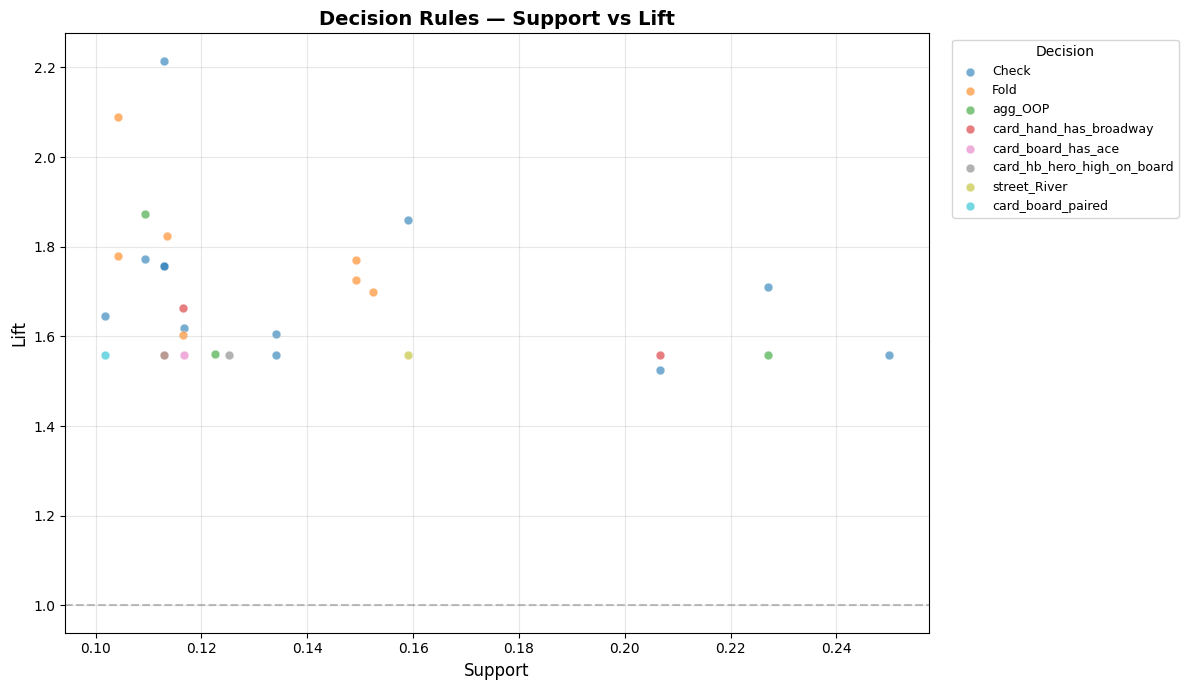

Saved: decision_rules_scatter.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Visualizations
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Poker Dataset — Frequent Itemset Bias Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Theoretical vs Observed bar chart --------------------------------
ax = axes[0, 0]
if len(df_compare) > 0:
    x_pos = np.arange(len(df_compare))
    w = 0.35
    ax.bar(x_pos - w/2, df_compare['Theoretical'], w, label='Theoretical (random deal)',
           color='#4A90D9', alpha=0.8, edgecolor='white')
    ax.bar(x_pos + w/2, df_compare['Observed'], w, label='Observed (dataset)',
           color='#D94A4A', alpha=0.8, edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_compare['Feature'], rotation=30, ha='right')
    ax.set_ylabel('Proportion')
    ax.set_title('Hand Feature: Theoretical vs Observed')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Top itemsets by support -----------------------------------------
ax = axes[0, 1]
# Show multi-item sets only (length ≥ 2) — singletons are less interesting
multi = freq_broad[freq_broad['length'] >= 2].head(20).copy()
if len(multi) > 0:
    multi['label'] = multi['itemsets'].apply(lambda s: '\n'.join(sorted(s)))
    multi = multi.sort_values('support')
    ax.barh(range(len(multi)), multi['support'], color='#5BAF6A', alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(multi)))
    ax.set_yticklabels(multi['label'], fontsize=7)
    ax.set_xlabel('Support')
    ax.set_title('Top 20 Multi-Item Frequent Itemsets (≥20% support)')
    ax.grid(axis='x', alpha=0.3)

# --- Plot 3: Lift distribution of bias rules ---------------------------------
ax = axes[1, 0]
if len(bias_rules) > 0:
    ax.hist(bias_rules['lift'], bins=40, color='#D9A04A', alpha=0.8, edgecolor='white')
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='Lift = 1 (independence)')
    ax.axvline(x=2.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Lift = 2')
    ax.set_xlabel('Lift')
    ax.set_ylabel('Number of Rules')
    ax.set_title('Lift Distribution — Input Feature Bias Rules')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# --- Plot 4: Position × Decision heatmap ------------------------------------
ax = axes[1, 1]
if 'hero_position' in df.columns:
    pos_dec = pd.crosstab(df['hero_position'], y, normalize='index')
    sns.heatmap(pos_dec, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Proportion'}, linewidths=0.5)
    ax.set_title('Decision Distribution by Position')
    ax.set_ylabel('Hero Position')
    ax.set_xlabel('Decision')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('itemset_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: itemset_bias_analysis.png")


# --- Bonus: Support × Lift scatter for decision rules (separate figure) ------
if len(decision_rules) > 0:
    fig2, ax2 = plt.subplots(figsize=(12, 7))

    # Color by which decision the rule predicts
    dec_labels = decision_rules['consequents'].apply(lambda s: list(s)[0].replace('dec_', ''))
    unique_decs = dec_labels.unique()
    cmap = plt.cm.get_cmap('tab10', len(unique_decs))
    color_map = {d: cmap(i) for i, d in enumerate(unique_decs)}

    for dec in unique_decs:
        mask = dec_labels == dec
        subset = decision_rules[mask]
        ax2.scatter(subset['support'], subset['lift'],
                    c=[color_map[dec]], label=dec, alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

    ax2.set_xlabel('Support', fontsize=12)
    ax2.set_ylabel('Lift', fontsize=12)
    ax2.set_title('Decision Rules — Support vs Lift', fontsize=14, fontweight='bold')
    ax2.legend(title='Decision', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('decision_rules_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: decision_rules_scatter.png")

Chi-Squared Stats

═══ CONTINGENCY TABLE (counts) ═══

decision_category  Bet/Raise   Call   Check   Fold
hero_position                                     
IP                     86629  60290  125000  48265
OOP                    38371  64710       0  76735

═══ CHI-SQUARED TEST: Position × Decision ═══

  χ²  statistic : 120,350.06
  p-value       : 0.00e+00
  Degrees of freedom: 3
  Result: SIGNIFICANT at α = 0.05

═══ STANDARDIZED RESIDUALS ═══
  (|value| > 2 ≈ significant cell-level departure)

decision_category  Bet/Raise   Call   Check    Fold
hero_position                                      
IP                     23.27 -69.83  158.89 -112.33
OOP                   -31.05  93.18 -212.02  149.89

═══ EFFECT SIZE ═══
  Cramér's V = 0.4906
  Interpretation: medium association


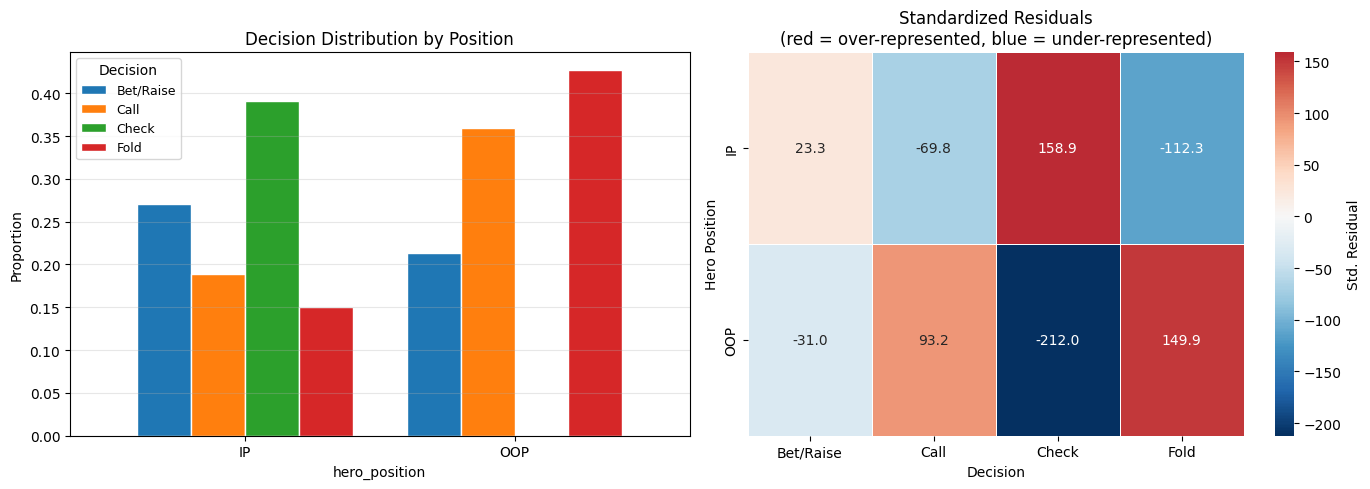

In [ ]:
###############################################################################
# CELL 7 — Chi-Squared Test: Position × Decision Category
###############################################################################

from scipy.stats import chi2_contingency

# --- Build contingency table ------------------------------------------------
contingency = pd.crosstab(df['hero_position'], y)
print("═══ CONTINGENCY TABLE (counts) ═══\n")
print(contingency)
print()

# --- Run chi-squared test ---------------------------------------------------
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("═══ CHI-SQUARED TEST: Position × Decision ═══\n")
print(f"  χ²  statistic : {chi2:,.2f}")
print(f"  p-value       : {p_value:.2e}")
print(f"  Degrees of freedom: {dof}")
print(f"  Result: {'SIGNIFICANT' if p_value < 0.05 else 'NOT significant'} at α = 0.05")

# --- Standardized residuals (where the dependence lives) --------------------
# (observed - expected) / sqrt(expected)
# Large positive = that cell occurs MORE than independence predicts
# Large negative = occurs LESS

residuals = (contingency.values - expected) / np.sqrt(expected)
df_residuals = pd.DataFrame(residuals,
                            index=contingency.index,
                            columns=contingency.columns)

print("\n═══ STANDARDIZED RESIDUALS ═══")
print("  (|value| > 2 ≈ significant cell-level departure)\n")
print(df_residuals.round(2).to_string())

# --- Cramér's V (effect size) -----------------------------------------------
n = contingency.values.sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f"\n═══ EFFECT SIZE ═══")
print(f"  Cramér's V = {cramers_v:.4f}")
if cramers_v < 0.1:
    interp = "negligible"
elif cramers_v < 0.3:
    interp = "small"
elif cramers_v < 0.5:
    interp = "medium"
else:
    interp = "large"
print(f"  Interpretation: {interp} association")

# --- Visualize residuals as heatmap -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Expected vs observed as grouped bar
ax = axes[0]
contingency_pct = pd.crosstab(df['hero_position'], y, normalize='index')
contingency_pct.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_ylabel('Proportion')
ax.set_title('Decision Distribution by Position')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Decision', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Residual heatmap
ax = axes[1]
sns.heatmap(df_residuals, annot=True, fmt='.1f', center=0,
            cmap='RdBu_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Std. Residual'})
ax.set_title('Standardized Residuals\n(red = over-represented, blue = under-represented)')
ax.set_ylabel('Hero Position')
ax.set_xlabel('Decision')

plt.tight_layout()
plt.savefig('chi_squared_position_decision.png', dpi=150, bbox_inches='tight')
plt.show()

- Fairly significant, can see the distribution is very different depending on the position